# Roteiro de Laboratório: Simulação Computacional da Visão Humana e Cor

### **Objetivos Didáticos:**

* Compreender a faixa do **espectro eletromagnético visível (400 a 700 nm)** e a absorção luminosa.
* Modelar a **sensibilidade dos cones (S, M, L)** na retina e diferenciar a **visão fotópica e escotópica**.
* Implementar a **Teoria Tricromática de Maxwell** e o **vetor cromático RGB**.

### **Bloco 1: Espectro Eletromagnético Visível (400 nm a 700 nm)**
O olho humano capta apenas uma estreita faixa da radiação eletromagnética, compreendida entre **400 nm e 700 nm**. Neste exercício, os alunos criam uma função para mapear comprimentos de onda em valores aproximados de cor RGB.


In [3]:
pip install matplotlib


   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 9.5/9.5 MB 56.1 MB/s  0:00:00
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   ---------------------------------------- 2.5/2.5 MB 29.5 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ----------------------- ---------------- 4.2/7.2 MB 20.7 MB/s eta 0:00:01
   ------------------------------------- -- 6.8/7.2 MB 17.2 MB/s eta 0:00:01
   ---------------------------------------- 7.2/7.2 MB 16.2 MB/s  0:00:00

   ---------------------------------------- 0/7 [pyparsing]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- -----

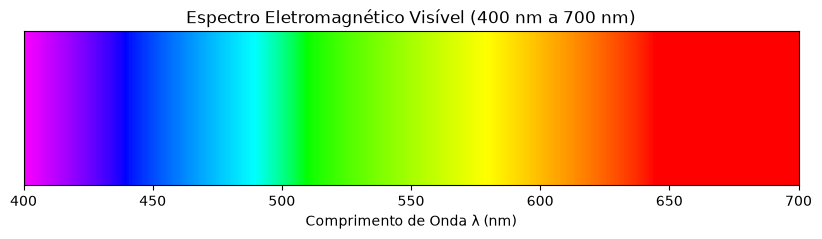

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def wavelength_to_rgb(wavelength):
    """Converte comprimento de onda em nanômetros (400-700 nm) para RGB aproximado."""
    gamma = 0.8
    if wavelength >= 400 and wavelength < 440:
        R = -(wavelength - 440) / (440 - 400)
        G = 0.0
        B = 1.0
    elif wavelength >= 440 and wavelength < 490:
        R = 0.0
        G = (wavelength - 440) / (490 - 440)
        B = 1.0
    elif wavelength >= 490 and wavelength < 510:
        R = 0.0
        G = 1.0
        B = -(wavelength - 510) / (510 - 490)
    elif wavelength >= 510 and wavelength < 580:
        R = (wavelength - 510) / (580 - 510)
        G = 1.0
        B = 0.0
    elif wavelength >= 580 and wavelength < 645:
        R = 1.0
        G = -(wavelength - 645) / (645 - 580)
        B = 0.0
    elif wavelength >= 645 and wavelength <= 700:
        R = 1.0
        G = 0.0
        B = 0.0
    else:
        R, G, B = 0.0, 0.0, 0.0

    return (R**gamma, G**gamma, B**gamma)

# Plot do espectro visível
wavelengths = np.linspace(400, 700, 300)
spectrum_colors = [wavelength_to_rgb(w) for w in wavelengths]

fig, ax = plt.subplots(figsize=(10, 2))
for i, w in enumerate(wavelengths):
    ax.axvline(x=w, color=spectrum_colors[i], linewidth=4)

ax.set_xlim(400, 700)
ax.set_title("Espectro Eletromagnético Visível (400 nm a 700 nm)")
ax.set_xlabel("Comprimento de Onda λ (nm)")
ax.get_yaxis().set_visible(False)
plt.show()

### **Bloco 2: Curvas de Resposta dos Fotorreceptores da Retina**
A retina contém cerca de **100 milhões de sensores**. A visão cromática (fotópica) baseia-se nos **três tipos de cones (S, M e L)** sensíveis a comprimentos de onda curtos, médios e longos.


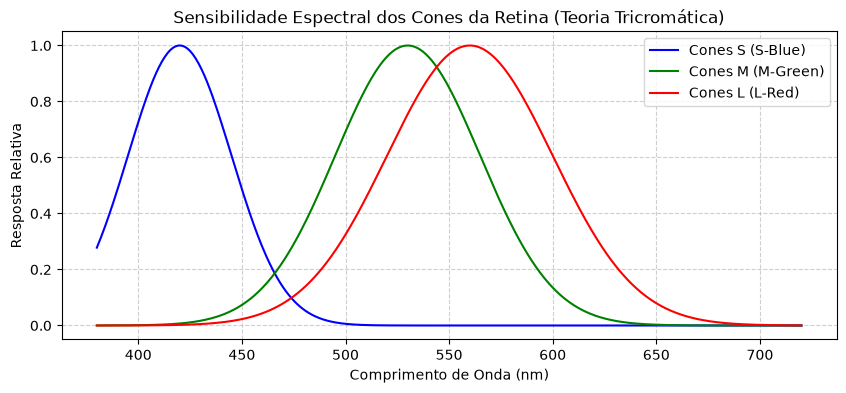

In [5]:
# Modelagem gaussiana simplificada da sensibilidade dos cones S, M e L
wl = np.linspace(380, 720, 500)

# Picos de sensibilidade aproximados: S (420nm - Azul), M (530nm - Verde), L (560nm - Vermelho)
cone_S = np.exp(-((wl - 420)**2) / (2 * 25**2))
cone_M = np.exp(-((wl - 530)**2) / (2 * 35**2))
cone_L = np.exp(-((wl - 560)**2) / (2 * 40**2))

plt.figure(figsize=(10, 4))
plt.plot(wl, cone_S, color='blue', label='Cones S (S-Blue)')
plt.plot(wl, cone_M, color='green', label='Cones M (M-Green)')
plt.plot(wl, cone_L, color='red', label='Cones L (L-Red)')

plt.title("Sensibilidade Espectral dos Cones da Retina (Teoria Tricromática)")
plt.xlabel("Comprimento de Onda (nm)")
plt.ylabel("Resposta Relativa")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

### **Bloco 3: Vetor Cromático \\(R, G, B\\) e Teoria de Maxwell**
Segundo a **Teoria de Maxwell**, a percepção da cor resulta da combinação das respostas dos três tipos de receptores da retina. A tabela a seguir reinterpreta os exemplos da **Tabela 2.3 da fonte**:

In [7]:
pip install pandas

  Using cached tzdata-2026.5-py2.py3-none-any.whl.metadata (1.4 kB)
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ---------------------------------------- 9.8/9.8 MB 48.5 MB/s  0:00:00
Using cached tzdata-2026.5-py2.py3-none-any.whl (347 kB)

   ---------------------------------------- 0/2 [tzdata]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2

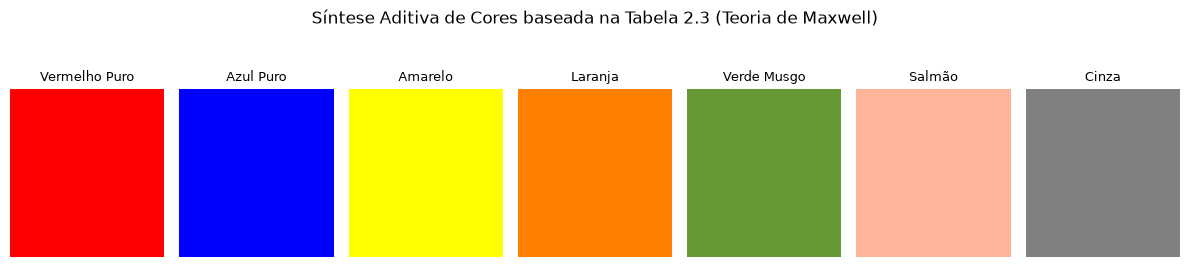

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Dados baseados na Tabela 2.3 do material de estudo
dados_vetor = {
    "Cor": ["Vermelho Puro", "Azul Puro", "Amarelo", "Laranja", "Verde Musgo", "Salmão", "Cinza"],
    "R (%)": [100, 0, 100, 100, 40, 100, 50],
    "G (%)": [0, 0, 100, 50, 60, 70, 50],
    "B (%)": [0, 100, 0, 0, 20, 60, 50],
}

df_cores = pd.DataFrame(dados_vetor)

# Renderiza as cores geradas pelo vetor cromático
fig, axes = plt.subplots(1, len(df_cores), figsize=(12, 2.5))

for i, row in df_cores.iterrows():
    rgb_color = (row["R (%)"] / 100.0, row["G (%)"] / 100.0, row["B (%)"] / 100.0)
    axes[i].add_patch(plt.Rectangle((0, 0), 1, 1, color=rgb_color))
    axes[i].set_title(row["Cor"], fontsize=9)
    axes[i].axis("off")

plt.suptitle("Síntese Aditiva de Cores baseada na Tabela 2.3 (Teoria de Maxwell)", y=1.05)
plt.tight_layout()
plt.show()


### **Bloco 4: Questões Desafio para os Alunos**

1. **Adaptação e Iluminação**: Explique a diferença entre a visão **escotópica** (noturna/bastonetes) e **fotópica** (diurna/cones) e como a alteração na intensidade afeta a percepção das cores.



2. **Daltonismo (Simulação)**: Altere o código do Bloco 3 para zerar a contribuição do canal \\(R\\) (simulando a *Protanopia*, ausência de cones L). Quais cores da tabela sofrem maior alteração visual?

### **1. Adaptação e Iluminação: Visão Escotópica vs. Fotópica**

* **Visão Fotópica (Diurna)**: Ocorre em ambientes com **alta intensidade luminosa**. É intermediada pelos **cones** da retina, que possuem três tipos de sensibilidade cromática (comprimentos de onda curtos, médios e longos — S, M e L). Nesse regime, o sistema visual humano opera com alta acuidade visual e percepção plena de cores.
* **Visão Escotópica (Noturna)**: Ocorre em ambientes de **baixa intensidade luminosa** (abaixo do limiar de resposta dos cones). É intermediada exclusivamente pelos **bastonetes**, que são fotorreceptores de alta sensibilidade luminosa, porém **monocromáticos**.
* **Efeito da Intensidade na Percepção de Cor**: À medida que a iluminação diminui até o nível escotópico, os cones deixam de ser estimulados. Como os bastonetes não diferenciam comprimentos de onda (não possuem receptores R, G e B distintos), **a percepção de cores é perdida**, e o cérebro passa a registrar a cena apenas em tons de cinza (variação de luminância).

---

### **2. Daltonismo (Simulação de Protanopia — Zerar Canal \\(R\\))**

Ao zerar o componente vermelho (\\(R = 0\%\\)) no vetor cromático \\((R, G, B)\\) da **Tabela 2.3**, a alteração visual de cada cor ocorre da seguinte forma:

| Cor Original | Vetor Original \\((R, G, B)\\) | Vetor Simulado \\((0, G, B)\\) | Nova Aparência Percebida | Nível de Alteração |
| :--- | :--- | :--- | :--- | :--- |
| **Vermelho puro** | \\((100, 0, 0)\\) | \\((0, 0, 0)\\) | **Preto** | **Total** (perda completa do estímulo) |
| **Amarelo** | \\((100, 100, 0)\\) | \\((0, 100, 0)\\) | **Verde puro** | **Drástica** (muda de amarelo para verde) |
| **Laranja** | \\((100, 50, 0)\\) | \\((0, 50, 0)\\) | **Verde escuro** | **Drástica** (perde o tom alaranjado) |
| **Salmão** | \\((100, 50, 50)\\) | \\((0, 50, 50)\\) | **Ciano / Azul-esverdeado** | **Drástica** (muda de tom quente para frio) |
| **Cinza** | \\((50, 50, 50)\\) | \\((0, 50, 50)\\) | **Ciano escuro** | **Moderada** (perde a neutralidade) |
| **Azul puro** | \\((0, 0, 100)\\) | \\((0, 0, 100)\\) | **Azul puro** | **Nenhuma** (já tinha \\(R = 0\%\\)) |
| **Verde musgo** | \\((0, 25, 0)\\) | \\((0, 25, 0)\\) | **Verde musgo** | **Nenhuma** (já tinha \\(R = 0\%\\)) |

**Cores com maior alteração visual:**
1. **Vermelho puro**: passa de uma cor primária brilhante para **preto / ausência de luz**, pois dependia \\(100\%\\) do canal \\(R\\).
2. **Amarelo e Laranja**: perdem totalmente a tonalidade avermelhada/quente e passam a ser percebidas como variações de **verde**.
3. **Salmão**: perde a componente vermelha e transforma-se em um tom de **ciano (azul-esverdeado)**.